# PENDULUM SWING - UP With SAC (Soft Actor Critic)

 ---
# Initialization, Replay Buffer, And Neural Network Architectures
  

In [11]:
import gymnasium as gym
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import pygame
#======================================
# CLASS 1: THE LINEAR OPERATOR BRICK
# =====================================================================
class DenseLayer: 
    def __init__(self, input_dim, output_dim): 
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.weights = np.random.randn(input_dim, output_dim) * 0.01
        self.bias = np.zeros((1, output_dim))
        self.input_data = None

    def ForwardPass(self, inputs): 
        self.input_data = inputs 
        return np.dot(inputs, self.weights) + self.bias

# =====================================================================
# CLASS 2: THE DATA STORAGE WAREHOUSE
# =====================================================================
class ReplayBuffer: 
    def __init__(self, action_size, state_size, max_size): 
        self.action_size = action_size
        self.state_size  = state_size 
        self.max_size    = max_size

        self.pointer = 0 
        self.current = 0

        self.actions = np.zeros((max_size, action_size))
        self.states  = np.zeros((max_size, state_size))
        self.reward  = np.zeros((max_size, 1))
        self.new_states = np.zeros_like(self.states)

    def store(self, state, action, reward, next_state):
        idx = self.pointer
        self.states[idx]     = state
        self.actions[idx]    = action
        self.reward[idx]     = reward
        self.new_states[idx] = next_state
        
        self.pointer = (self.pointer + 1) % self.max_size
        self.current = min(self.current + 1, self.max_size)

    def sample(self, batch_size):
        rand_indices = np.random.choice(self.current, batch_size, replace=False)
        return (
            self.states[rand_indices],
            self.actions[rand_indices],
            self.reward[rand_indices],
            self.new_states[rand_indices]
        )

# =====================================================================
# CLASS 3: THE TWIN CRITIC NETWORKS
# =====================================================================
class CriticNetwork: 
    def __init__(self, state_dim, action_dim, hidden_dim=256): 
        total_input = action_dim + state_dim 
        self.layer1 = DenseLayer(total_input, hidden_dim)
        self.layer2 = DenseLayer(hidden_dim, hidden_dim)
        self.layer3 = DenseLayer(hidden_dim, 1)

    def forward(self, state, action):
        x = np.hstack((state, action))
        x = self.layer1.ForwardPass(x)
        x = np.maximum(0, x)
        x = self.layer2.ForwardPass(x)
        x = np.maximum(0, x)
        q_values = self.layer3.ForwardPass(x)
        return q_values

# =====================================================================
# CLASS 4: THE STOCHASTIC PLAYER NETWORK
# =====================================================================
class ActorNetwork: 
    def __init__(self, state_dim, action_dim, hidden_dim=256): 
        self.layer1 = DenseLayer(state_dim, hidden_dim)
        self.layer2 = DenseLayer(hidden_dim, hidden_dim)
        
        self.mean_layer = DenseLayer(hidden_dim, action_dim)
        self.log_std_layer = DenseLayer(hidden_dim, action_dim) 

    def ForwardPass(self, state): 
        x = self.layer1.ForwardPass(state)
        x = np.maximum(0, x)

        x = self.layer2.ForwardPass(x)
        x = np.maximum(0, x) 

        mean = self.mean_layer.ForwardPass(x)
        log_std = self.log_std_layer.ForwardPass(x) 

        log_std = np.clip(log_std, -20, 2)
        std = np.exp(log_std)

        return mean, std

# Training my Agent

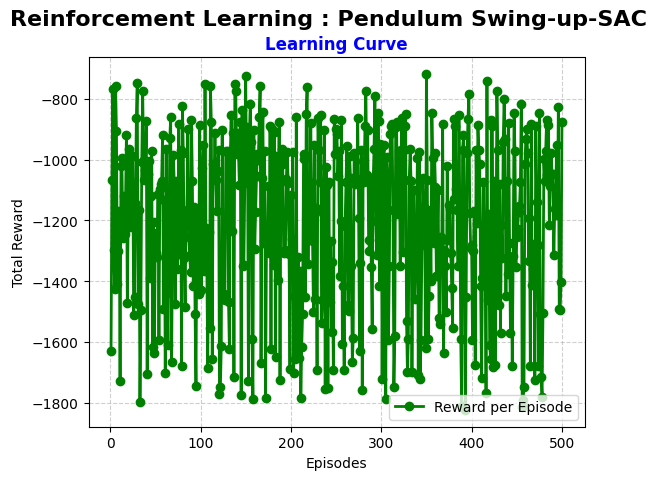

Episode Slot [500/500] -> Moving Average Reward: -875.42

Training Complete! The environment has been shut down cleanly.


In [16]:
# =====================================================================
# STEP 1: OBJECT INSTANTIATION & RUNTIME CONFIGURATION
# =====================================================================
# Hyperparameters
STATE_DIM = 3
ACTION_DIM = 1
BUFFER_SIZE = 100000
BATCH_SIZE = 64
GAMMA = 0.99
LR = 0.001
PRINT_FREQ = 1  
TOTAL_EPISODES = 500
MAX_STEPS_PER_EPISODE = 200

# Instantiate objects directly inside Cell 2
memory_vault = ReplayBuffer(action_size=ACTION_DIM, state_size=STATE_DIM, max_size=BUFFER_SIZE)
critic_1     = CriticNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM)
critic_2     = CriticNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM)
actor_net    = ActorNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM)

# Launch the physics engine
env = gym.make('Pendulum-v1', render_mode='human')

# Performance metrics arrays
history_episodes = []
history_rewards = []

# Initialize live plotting canvas window
fig, ax = plt.subplots()

print("Step 1 Complete: All objects built. Launching the main training engine interaction loops...")

# =====================================================================
# MAIN RUNTIME ENGINE (STEPS 2, 3, & 4)
# =====================================================================
for episode in range(TOTAL_EPISODES):
    state, info = env.reset()
    state = np.reshape(state, (1, 3))
    total_episode_reward = 0
    
    for step in range(MAX_STEPS_PER_EPISODE):
        # -------------------------------------------------------------
        # STEP 2: THE DATA GATHERING PHASE (INTERACTION)
        # -------------------------------------------------------------
        mean, std = actor_net.ForwardPass(state)
        noise = np.random.randn(*mean.shape)
        raw_action = mean + std * noise
        action = np.tanh(raw_action) * 2.0
        
        next_state, reward, terminated, truncated, info = env.step(action[0])
        next_state = np.reshape(next_state, (1, 3))
        done = terminated or truncated
        
        # Save step memory vector row
        memory_vault.store(state[0], action[0], reward, next_state[0])
        
        # -------------------------------------------------------------
        # STEP 3: THE BRAIN TRAINING PHASE (THE MATRIX UPDATES)
        # -------------------------------------------------------------
        if memory_vault.current >= BATCH_SIZE:
            b_states, b_actions, b_rewards, b_next_states = memory_vault.sample(BATCH_SIZE)
            
            # --- [TARGET Q-ESTIMATION CALCULUS ENGINE] ---
            next_means, next_stds = actor_net.ForwardPass(b_next_states)
            next_noises = np.random.randn(*next_means.shape)
            b_next_actions = np.tanh(next_means + next_stds * next_noises) * 2.0
            
            target_q1 = critic_1.forward(b_next_states, b_next_actions)
            target_q2 = critic_2.forward(b_next_states, b_next_actions)
            min_target_q = np.minimum(target_q1, target_q2)
            
            # Bellman Equation Target Label: Y = R + Gamma * Min_Q
            y_true = b_rewards + (GAMMA * min_target_q)
            
            # Compute current forward predictions
            y_pred1 = critic_1.forward(b_states, b_actions)
            y_pred2 = critic_2.forward(b_states, b_actions)
            
            # ---------------------------------------------------------
            # CRITIC 1 BACKPROPAGATION ENGINE
            # ---------------------------------------------------------
            grad_y1 = (y_pred1 - y_true) / BATCH_SIZE
            
            # Layer 3 Backpropagation
            dW3_c1 = np.dot(critic_1.layer3.input_data.T, grad_y1)
            dB3_c1 = np.sum(grad_y1, axis=0, keepdims=True)
            
            # Layer 2 Backpropagation + Activation Derivative Mask
            grad_layer2_c1 = np.dot(grad_y1, critic_1.layer3.weights.T)
            grad_layer2_c1[critic_1.layer3.input_data <= 0] = 0 
            dW2_c1 = np.dot(critic_1.layer2.input_data.T, grad_layer2_c1)
            dB2_c1 = np.sum(grad_layer2_c1, axis=0, keepdims=True)
            
            # Layer 1 Backpropagation + Activation Derivative Mask
            grad_layer1_c1 = np.dot(grad_layer2_c1, critic_1.layer2.weights.T)
            grad_layer1_c1[critic_1.layer2.input_data <= 0] = 0 
            dW1_c1 = np.dot(critic_1.layer1.input_data.T, grad_layer1_c1)
            dB1_c1 = np.sum(grad_layer1_c1, axis=0, keepdims=True)
            
            # Tweak Critic 1 Weights using standard SGD rules
            critic_1.layer3.weights -= LR * dW3_c1
            critic_1.layer3.bias    -= LR * dB3_c1
            critic_1.layer2.weights -= LR * dW2_c1
            critic_1.layer2.bias    -= LR * dB2_c1
            critic_1.layer1.weights -= LR * dW1_c1
            critic_1.layer1.bias    -= LR * dB1_c1
            
            # ---------------------------------------------------------
            # CRITIC 2 BACKPROPAGATION ENGINE
            # ---------------------------------------------------------
            grad_y2 = (y_pred2 - y_true) / BATCH_SIZE
            
            # Layer 3 Backpropagation
            dW3_c2 = np.dot(critic_2.layer3.input_data.T, grad_y2)
            dB3_c2 = np.sum(grad_y2, axis=0, keepdims=True)
            
            # Layer 2 Backpropagation + Activation Derivative Mask
            grad_layer2_c2 = np.dot(grad_y2, critic_2.layer3.weights.T)
            grad_layer2_c2[critic_2.layer3.input_data <= 0] = 0 
            dW2_c2 = np.dot(critic_2.layer2.input_data.T, grad_layer2_c2)
            dB2_c2 = np.sum(grad_layer2_c2, axis=0, keepdims=True)
            
            # Layer 1 Backpropagation + Activation Derivative Mask
            grad_layer1_c2 = np.dot(grad_layer2_c2, critic_2.layer2.weights.T)
            grad_layer1_c2[critic_2.layer2.input_data <= 0] = 0 
            dW1_c2 = np.dot(critic_2.layer1.input_data.T, grad_layer1_c2)
            dB1_c2 = np.sum(grad_layer1_c2, axis=0, keepdims=True)
            
            # Tweak Critic 2 Weights using standard SGD rules
            critic_2.layer3.weights -= LR * dW3_c2
            critic_2.layer3.bias    -= LR * dB3_c2
            critic_2.layer2.weights -= LR * dW2_c2
            critic_2.layer2.bias    -= LR * dB2_c2
            critic_2.layer1.weights -= LR * dW1_c2
            critic_2.layer1.bias    -= LR * dB1_c2

        state = next_state
        total_episode_reward += reward
        
        if done:
            break
            
    # Accumulate episode history data rows
    history_episodes.append(episode + 1)
    history_rewards.append(total_episode_reward)
    
    # -------------------------------------------------------------
    # STEP 4: TRACKING & LIVE REAL-TIME VISUALIZATION
    # -------------------------------------------------------------
    if (episode + 1) % PRINT_FREQ == 0:
        clear_output(wait=True)

        fig.suptitle("Reinforcement Learning : Pendulum Swing-up-SAC", fontsize=16, fontweight='bold')
        ax.clear()
        
        ax.plot(history_episodes, history_rewards, color='green',marker='o' , linewidth=2, label='Reward per Episode')
        
        ax.set_xlabel('Episodes')
        ax.set_title("Learning Curve" , fontsize=12 ,fontweight='bold' ,color='blue')
        ax.set_ylabel('Total Reward')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='lower right')
        
        display(fig)
        
        avg_reward = np.mean(history_rewards[-PRINT_FREQ:])
        print(f"Episode Slot [{episode + 1:03d}/{TOTAL_EPISODES}] -> Moving Average Reward: {avg_reward:.2f}")

plt.close()
env.close()
print("\nTraining Complete! The environment has been shut down cleanly.")